# Data transformations

In this document we will examine how the models transform the data, before proceeding to the multiclass classification task. The models that under evaluation are a Transformer and a LSTM. For the data visualization, t-SNE and UMAP will be used followed by their results comparison.

## Dataset and tools loading
Loading the required libraries and datasets needed to train and test the models.

In [1]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
from torcheval.metrics import MulticlassAccuracy
import sys
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from utils import dataset_utils
from utils import train_test_utils as ttutils
from utils.models import MyTransformerModel, MyLSTMClassifier

from IPython.utils.io import capture_output

print(sys.path)

def load_config(file_path):
    with open(file_path, "r") as file:
        json_data = json.load(file)
        config = json_data["config"]
    return config

dataset_file = "/mnt/btrfs/datasets/cybersecurity/multiclass/cybersecurity-unified-multiclass.csv"
dataset_name = os.path.basename(dataset_file).split(".")[0]
lstm_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_lstm_{dataset_name}.pt")
lstm_removed_sep_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_lstm_{dataset_name}_sep_removed.pt")
lstm_removed_uni_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_lstm_{dataset_name}_uni_removed.pt")
transformer_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_transformer_{dataset_name}.pt")
transformer_sep_removed_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_transformer_{dataset_name}_sep_removed.pt")
transformer_uni_removed_model_file = os.path.join(parent_dir, "results", "trained_models", f"best_model_transformer_{dataset_name}_uni_removed.pt")

rows_limit = 250e+3
chunk_size = 3e+6
DEVICE = ttutils.get_device()
TRANSFORMER_EPOCHS = 45
LSTM_EPOCHS = 10

with capture_output():
    csv_dataset = dataset_utils.CSVDataset(dataset_file, "Label", columns_to_drop=["Timestamp"], chunk_size=chunk_size)
    csv_dataset.load(rows_limit=rows_limit)

features, category_map, n_classes = csv_dataset.features, csv_dataset.categories, csv_dataset.n_classes
dataset_df = pd.DataFrame(csv_dataset.X.numpy(), columns=csv_dataset.features, dtype="float32")
dataset_df["Label"] = csv_dataset.y.numpy()
y = csv_dataset.y
X = csv_dataset.X
del csv_dataset

dataset_lstm_removed_df = dataset_df.drop(columns=["Fwd Seg Size Min", "Label"])
dataset_transformer_removed_df = dataset_df.drop(columns=["Src IP", "Dst IP", "Idle Mean", "Idle Min", "Idle Max", "Label"])
dataset_unified_removed_df = dataset_df.drop(columns=["Src IP", "Dst IP", "Fwd Seg Size Min", "Init Bwd Win Byts",
                                                        "Idle Mean", "Idle Min", "Idle Max", "Label"])

X_lstm_removed = torch.from_numpy(dataset_lstm_removed_df.to_numpy(dtype="float32"))
X_transformer_removed = torch.from_numpy(dataset_transformer_removed_df.to_numpy(dtype="float32"))
X_unified_removed = torch.from_numpy(dataset_unified_removed_df.to_numpy(dtype="float32"))
del dataset_lstm_removed_df, dataset_transformer_removed_df, dataset_unified_removed_df

print(category_map)
print(X.shape, X_lstm_removed.shape, X_transformer_removed.shape, X_unified_removed.shape)

dataset = TensorDataset(X,y)
dataset_lstm_removed = TensorDataset(X_lstm_removed, y)
dataset_transformer_removed = TensorDataset(X_transformer_removed, y)
dataset_unified_removed = TensorDataset(X_unified_removed, y)

del X, X_lstm_removed, X_transformer_removed, X_unified_removed, y
dataset_df


['/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib64/python3.13/site-packages/ray/thirdparty_files', '/usr/lib64/python313.zip', '/usr/lib64/python3.13', '/usr/lib64/python3.13/lib-dynload', '', '/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib64/python3.13/site-packages', '/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib/python3.13/site-packages', '/tmp/tmpfyx7y3wv', '/home/sbaltsas/Visual_Studio_Code_Projects/thesis']
CUDA available! GPU device name is: NVIDIA GeForce RTX 4060
{0: 'Botnet', 1: 'DoS', 2: 'MITM', 3: 'Normal', 4: 'Scanner', 5: 'Brute force', 6: 'Generic', 7: 'Exploit', 8: 'Infection'}
torch.Size([150903, 81]) torch.Size([150903, 80]) torch.Size([150903, 76]) torch.Size([150903, 74])


,Src IP,Src Port,Dst IP,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3.232261e+09,17832.0,6.938373e+08,37215.0,6.0,5.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0
1,3.232261e+09,17832.0,2.623911e+09,37215.0,6.0,1.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0
2,3.232261e+09,17832.0,3.319080e+09,37215.0,6.0,2.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0
3,3.232261e+09,17832.0,2.632667e+09,37215.0,6.0,4.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0
4,3.232261e+09,17832.0,6.902551e+08,37215.0,6.0,5.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150898,2.261863e+09,4554.0,2.261863e+09,51468.0,6.0,1465.0,3.0,3.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,1.551395e+15,409.644958,1.551395e+15,1.551395e+15,8
150899,2.808330e+09,80.0,3.232236e+09,52728.0,6.0,47218.0,1.0,3.0,582.0,0.0,...,32.0,0.0,0.0,0.0,0.0,1.551378e+15,0.000000,1.551378e+15,1.551378e+15,8
150900,3.232236e+09,32239.0,1.528230e+09,52869.0,6.0,10292433.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,1.029243e+07,0.000000,1.029243e+07,1.029243e+07,8
150901,3.232236e+09,54836.0,3.232236e+09,52869.0,6.0,2053053.0,2.0,0.0,0.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,8


## Training models and data transformation

In order to visualize the data transformation of the best model, we need to train the model first on the 90% of the dataset. The rest 10% will be used for visualization needs.

### Training
#### Transformer

In [20]:
transformer_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_transformer", "best_config_multiclass.json")
config = load_config(transformer_config_file)
learning_rate = config.pop("lr")
batch_size = config.pop("batch_size")
transformer_hyperparameters = config
enc_embed_dim = config["enc_embedding_dim"]
transformer_model = MyTransformerModel(dataset.tensors[0].shape[1], n_classes, **transformer_hyperparameters)

transformer_removed_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_removed_features_transformer", "improved_removed_features_best_config.json")
config = load_config(transformer_removed_config_file)
learning_removed_rate = config.pop("lr")
batch_removed_size = config.pop("batch_size")
transformer_removed_hyperparameters = config
enc_embed_dim_removed = config["enc_embedding_dim"]
transformer_sep_removed_model = MyTransformerModel(dataset_transformer_removed.tensors[0].shape[1], n_classes, **transformer_removed_hyperparameters)
transformer_uni_removed_model = MyTransformerModel(dataset_unified_removed.tensors[0].shape[1], n_classes, **transformer_removed_hyperparameters)

# training transformer with all network specific features included
train_data, test_data = random_split(dataset, [0.9, 0.1])
train_loader = DataLoader(train_data, batch_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
transformer_model.to(DEVICE)
ttutils.train_model(transformer_model, transformer_model_file, train_loader, None, metric=train_metric, learning_rate=learning_rate, epochs=TRANSFORMER_EPOCHS)

Epoch 1/45. Average train accuracy: 51.302%, average loss: 1.26864, current loss: 1.39093.
Saved model!
Epoch 2/45. Average train accuracy: 57.090%, average loss: 1.07863, current loss: 0.45597.
Saved model!
Epoch 3/45. Average train accuracy: 58.809%, average loss: 1.03877, current loss: 1.05998.
Saved model!
Epoch 4/45. Average train accuracy: 60.418%, average loss: 1.00580, current loss: 0.71907.
Saved model!
Epoch 5/45. Average train accuracy: 61.298%, average loss: 0.98140, current loss: 1.18659.
Saved model!
Epoch 6/45. Average train accuracy: 62.168%, average loss: 0.95878, current loss: 1.08530.
Saved model!
Epoch 7/45. Average train accuracy: 63.013%, average loss: 0.92684, current loss: 0.38834.
Saved model!
Epoch 8/45. Average train accuracy: 63.952%, average loss: 0.88934, current loss: 0.56555.
Saved model!
Epoch 9/45. Average train accuracy: 64.537%, average loss: 0.86619, current loss: 0.73253.
Saved model!
Epoch 10/45. Average train accuracy: 64.984%, average loss: 0.85

In [21]:
# training transformer with separate removed network specific features
train_sep_removed_data, test_sep_removed_data = random_split(dataset_transformer_removed, [0.9, 0.1])
train_loader = DataLoader(train_sep_removed_data, batch_removed_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
transformer_sep_removed_model.to(DEVICE)
ttutils.train_model(transformer_sep_removed_model, transformer_sep_removed_model_file, train_loader, None, metric=train_metric, 
                    learning_rate=learning_removed_rate, epochs=TRANSFORMER_EPOCHS)

Epoch 1/45. Average train accuracy: 80.758%, average loss: 0.52288, current loss: 0.31230.
Saved model!
Epoch 2/45. Average train accuracy: 89.047%, average loss: 0.29478, current loss: 0.43255.
Saved model!
Epoch 3/45. Average train accuracy: 90.199%, average loss: 0.25803, current loss: 0.37849.
Saved model!
Epoch 4/45. Average train accuracy: 89.548%, average loss: 0.27406, current loss: 0.28384.
Epoch 5/45. Average train accuracy: 90.920%, average loss: 0.23456, current loss: 0.32308.
Saved model!
Epoch 6/45. Average train accuracy: 90.628%, average loss: 0.24408, current loss: 0.29879.
Epoch 7/45. Average train accuracy: 91.147%, average loss: 0.22243, current loss: 0.30787.
Saved model!
Epoch 8/45. Average train accuracy: 90.946%, average loss: 0.23129, current loss: 0.29978.
Epoch 9/45. Average train accuracy: 91.534%, average loss: 0.21314, current loss: 0.13708.
Saved model!
Epoch 10/45. Average train accuracy: 91.180%, average loss: 0.22700, current loss: 0.25285.
Epoch 11/45

In [22]:
# training transformer with unified removed network specific features
train_uni_removed_data, test_uni_removed_data = random_split(dataset_unified_removed, [0.9, 0.1])
train_loader = DataLoader(train_uni_removed_data, batch_removed_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
transformer_uni_removed_model.to(DEVICE)
ttutils.train_model(transformer_uni_removed_model, transformer_uni_removed_model_file, train_loader, None, metric=train_metric, 
                    learning_rate=learning_removed_rate, epochs=TRANSFORMER_EPOCHS)

Epoch 1/45. Average train accuracy: 80.131%, average loss: 0.53734, current loss: 0.28188.
Saved model!
Epoch 2/45. Average train accuracy: 89.072%, average loss: 0.30020, current loss: 0.36381.
Saved model!
Epoch 3/45. Average train accuracy: 89.894%, average loss: 0.26912, current loss: 0.14852.
Saved model!
Epoch 4/45. Average train accuracy: 90.656%, average loss: 0.24262, current loss: 0.75559.
Saved model!
Epoch 5/45. Average train accuracy: 90.853%, average loss: 0.23609, current loss: 0.14428.
Saved model!
Epoch 6/45. Average train accuracy: 90.835%, average loss: 0.23939, current loss: 0.24478.
Epoch 7/45. Average train accuracy: 91.302%, average loss: 0.22149, current loss: 0.21209.
Saved model!
Epoch 8/45. Average train accuracy: 91.048%, average loss: 0.23024, current loss: 0.26836.
Epoch 9/45. Average train accuracy: 91.446%, average loss: 0.21416, current loss: 0.14599.
Saved model!
Epoch 10/45. Average train accuracy: 91.112%, average loss: 0.22608, current loss: 0.27655

### Inference and data transformation
#### Transformer
**All network specific features included**

KL divergence: 0.33635348081588745


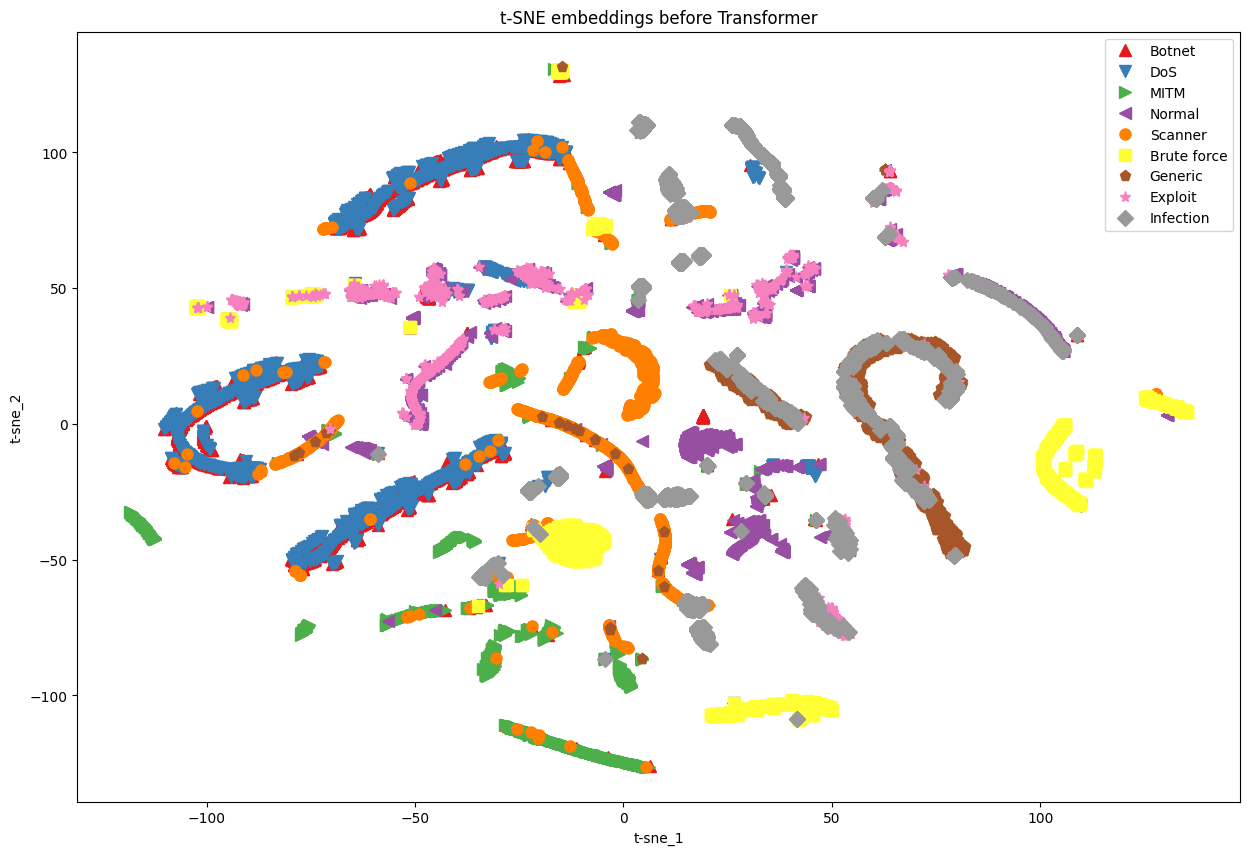

/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib64/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


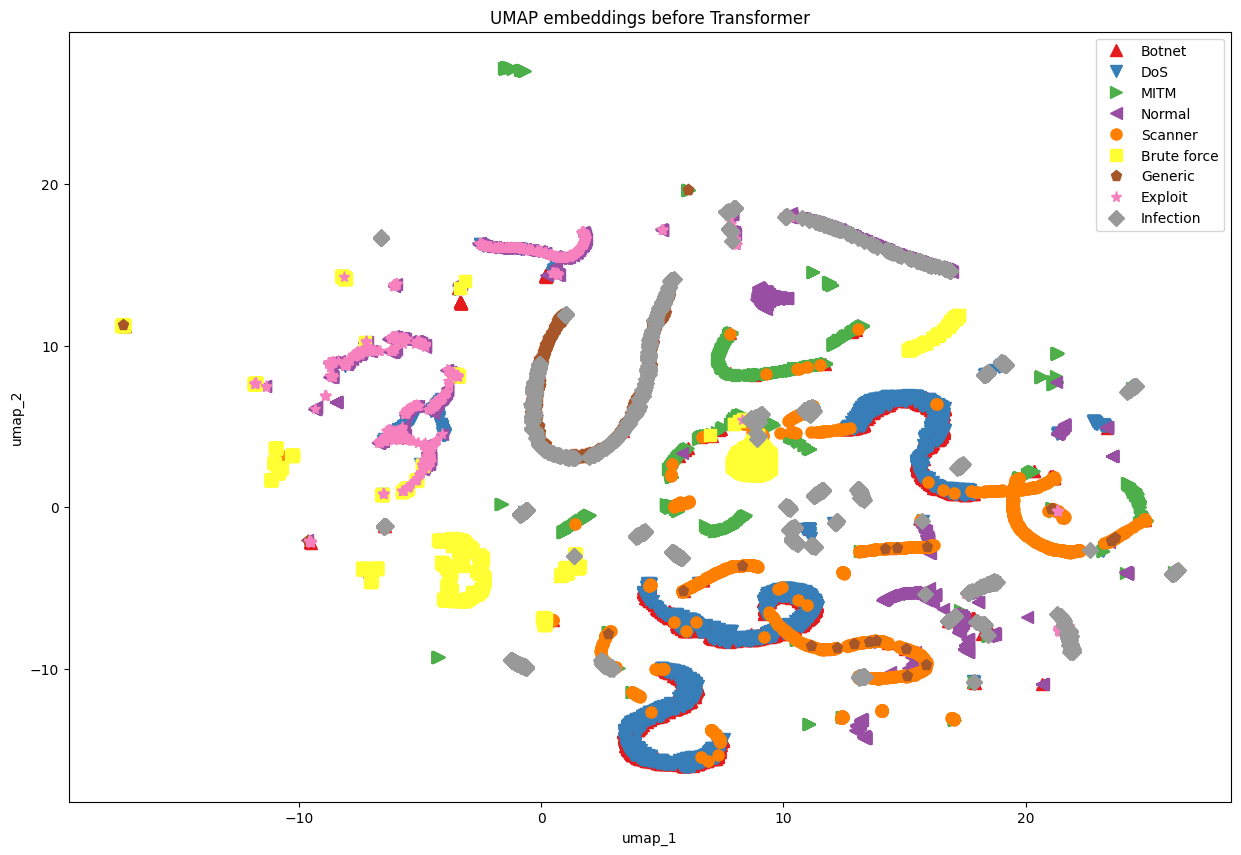

In [25]:
umap_reducer = umap.UMAP(n_components=2, n_neighbors=60, n_jobs=-1, min_dist=0.2)
tsne_reducer = TSNE(n_components=2, perplexity=50, method="barnes_hut", n_jobs=-1, max_iter=2000)

X_test, y_test = test_data.dataset[test_data.indices][0], test_data.dataset[test_data.indices][1]
embedding = tsne_reducer.fit_transform(X_test)
print("KL divergence:", tsne_reducer.kl_divergence_)

def plot_embedding(embedding, y_test, reducer_type="umap", title="plot"):
    import matplotlib as mpl
    colors = mpl.colormaps["Set1"].colors[:n_classes]
    markers = ("^", "v", ">", "<", "o", "s", "p", "*", "D")
    df = pd.DataFrame(embedding, columns=[f"{reducer_type}_1", f"{reducer_type}_2"])
    df["Label"] = y_test
    df.shape
    groups = df.groupby("Label")
    fig = plt.figure(figsize=((15,10)))
    ax = fig.add_subplot()
    for i, group in enumerate(groups):
        name, group_data = group
        ax.plot(group_data[f"{reducer_type}_1"], group_data[f"{reducer_type}_2"], marker=markers[i], 
                color=colors[i], linestyle='', label=category_map[name], markersize=8)
    ax.legend()
    ax.set_xlabel(f"{reducer_type}_1")
    ax.set_ylabel(f"{reducer_type}_2")
    ax.set_title(title)
    plt.show()

plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings before Transformer")
embedding = umap_reducer.fit_transform(X_test)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings before Transformer")


81
KL divergence: 0.40788698196411133


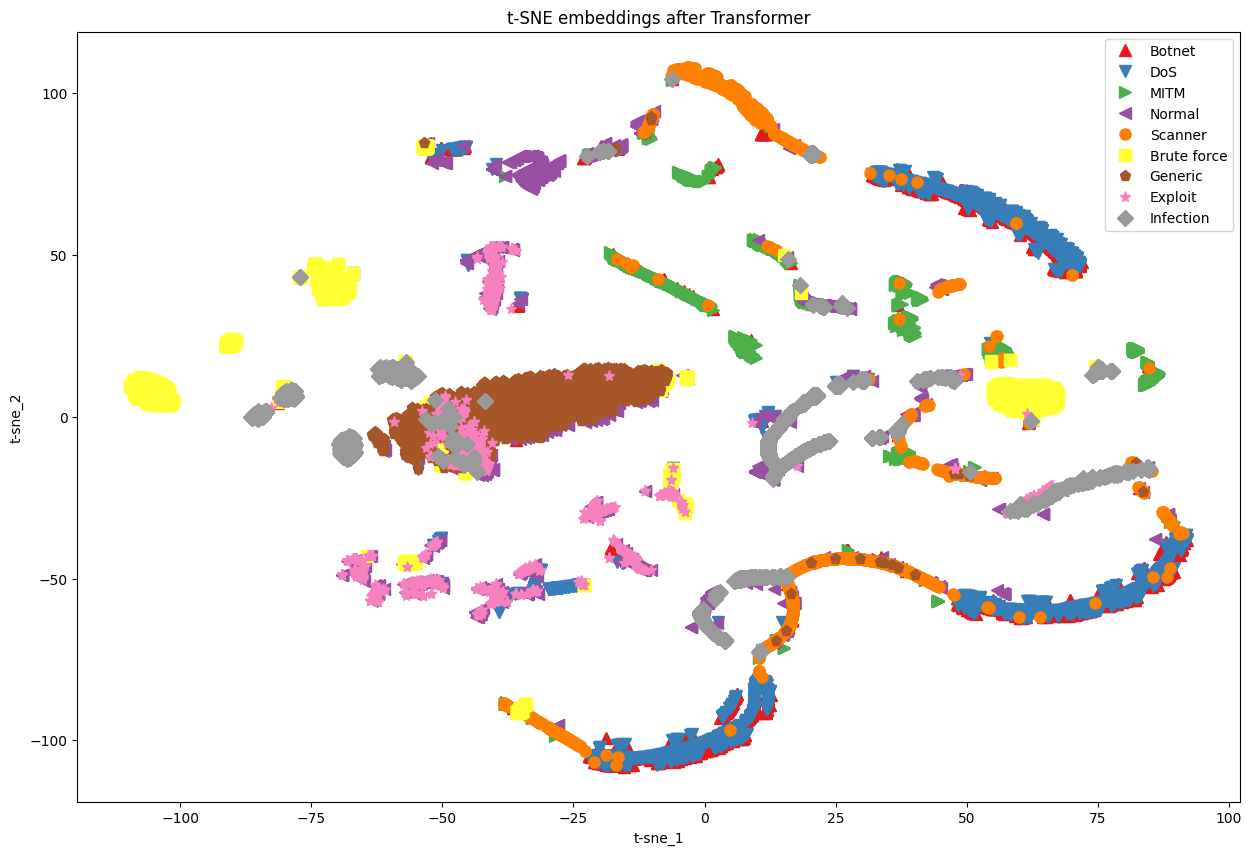

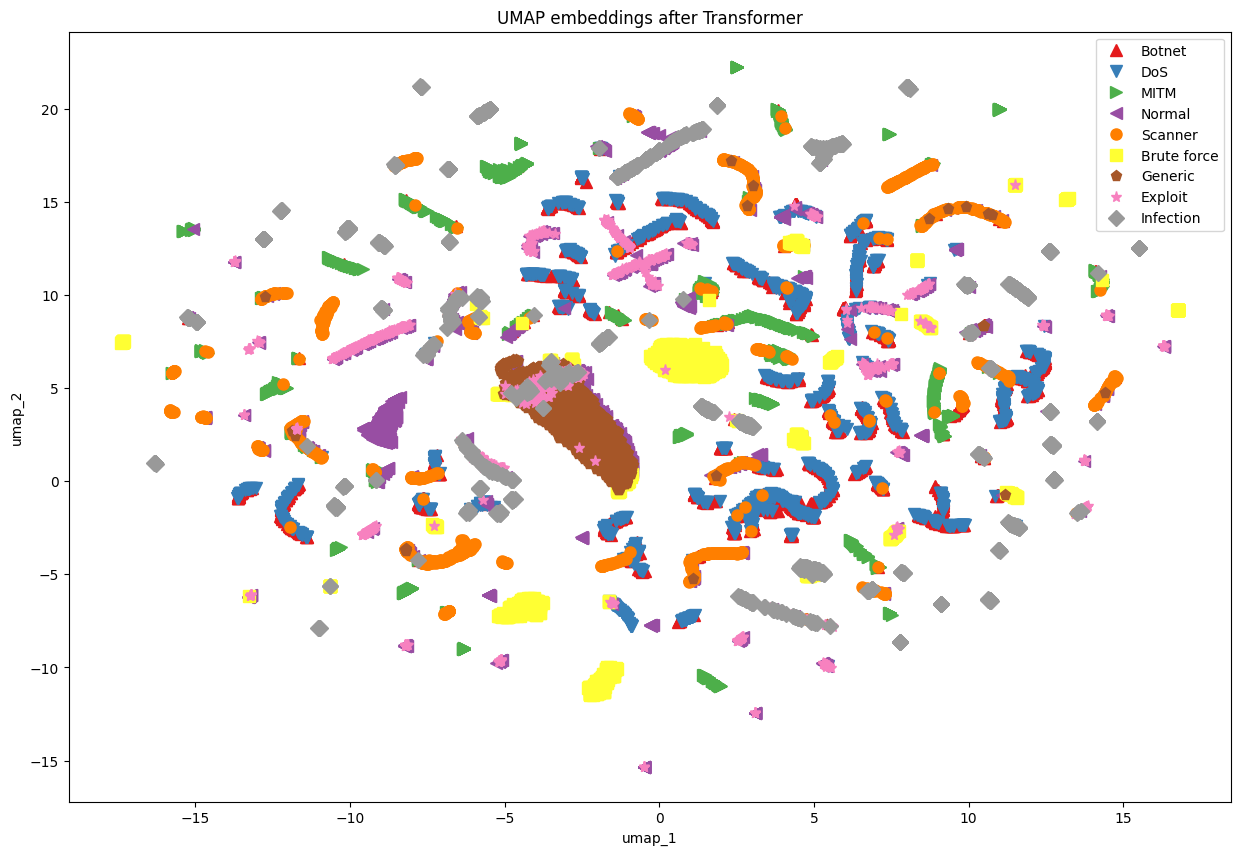

In [27]:
tsne_reducer = TSNE(n_components=2, perplexity=80, method="barnes_hut", n_jobs=-1, max_iter=2000)
transformer_model = MyTransformerModel(X_test.shape[1], n_classes, **transformer_hyperparameters).to(DEVICE)
transformer_model.load_state_dict(torch.load(transformer_model_file, weights_only=True))
transformer_model.eval()
transformer_output = torch.empty((X_test.shape[0], 64), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_data, batch_size=batch_size, pin_memory=True, num_workers=8, shuffle=False)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        n = data.shape[0]
        data = data.to(DEVICE)
        transformer_output[offset:offset+n] = transformer_model.transformer_layers(data)
        offset += n
assert offset == transformer_output.shape[0]

transformer_output = transformer_output.to("cpu")
embedding = tsne_reducer.fit_transform(transformer_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after Transformer")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=30, n_jobs=-1, min_dist=0.2)
embedding = umap_reducer.fit_transform(transformer_output)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings after Transformer")

**Network specific features removed separatively**

KL divergence: -0.050694696605205536


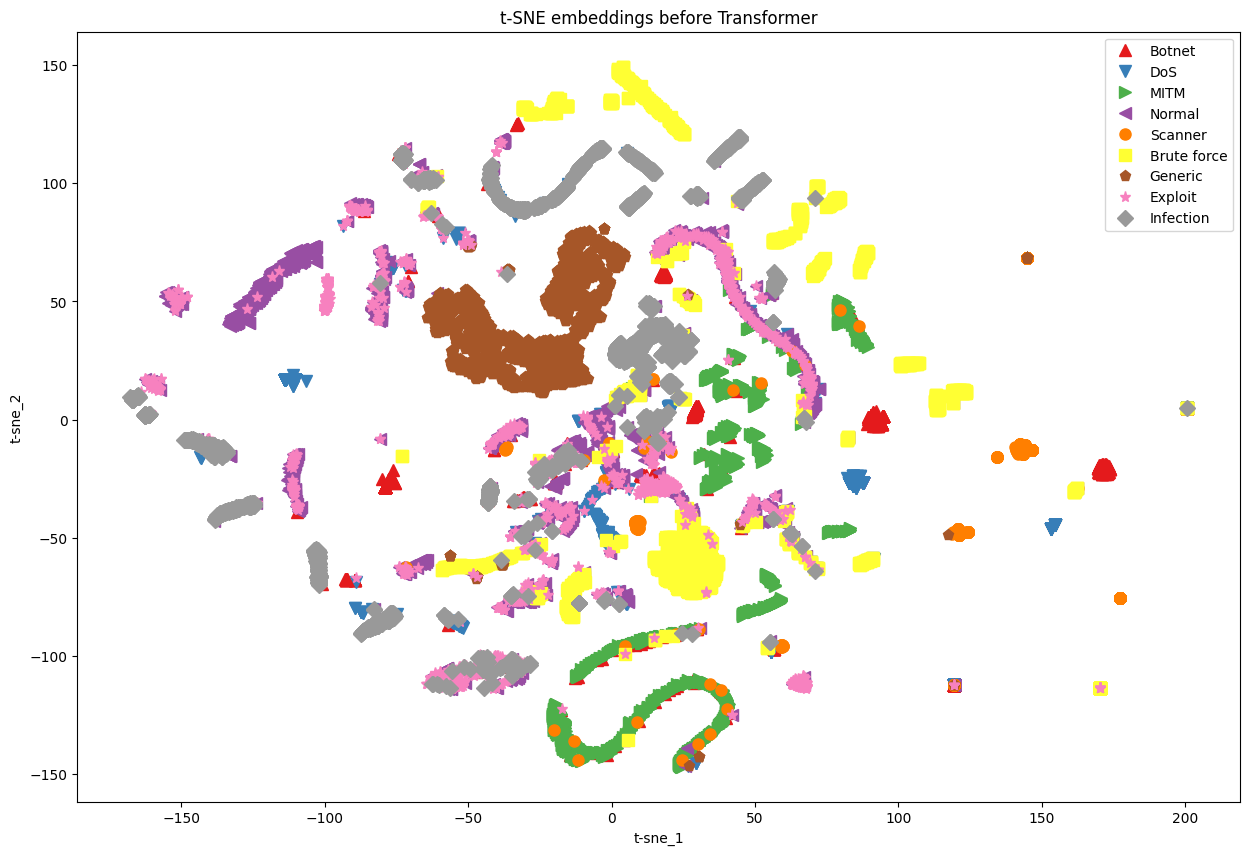

/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib64/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


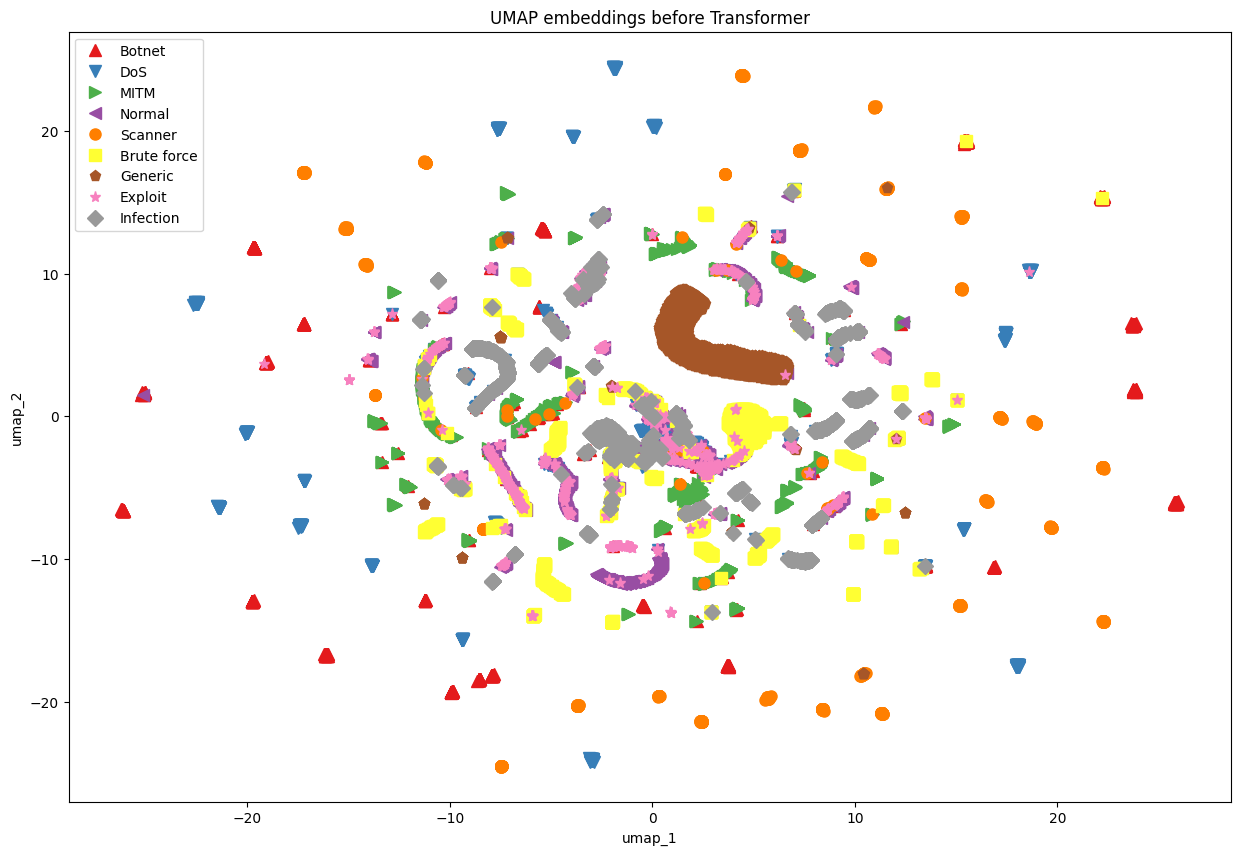

In [28]:
tsne_reducer = TSNE(n_components=2, perplexity=30, method="barnes_hut", n_jobs=-1, max_iter=2000)
X_test, y_test = test_sep_removed_data.dataset[test_sep_removed_data.indices][0], test_sep_removed_data.dataset[test_sep_removed_data.indices][1]
embedding = tsne_reducer.fit_transform(X_test)
print("KL divergence:", tsne_reducer.kl_divergence_)
embedding.shape
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings before Transformer")
umap_reducer = umap.UMAP(n_components=2, n_neighbors=25, n_jobs=-1, min_dist=0.2)
embedding = umap_reducer.fit_transform(X_test)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings before Transformer")

76
KL divergence: 0.2940236032009125


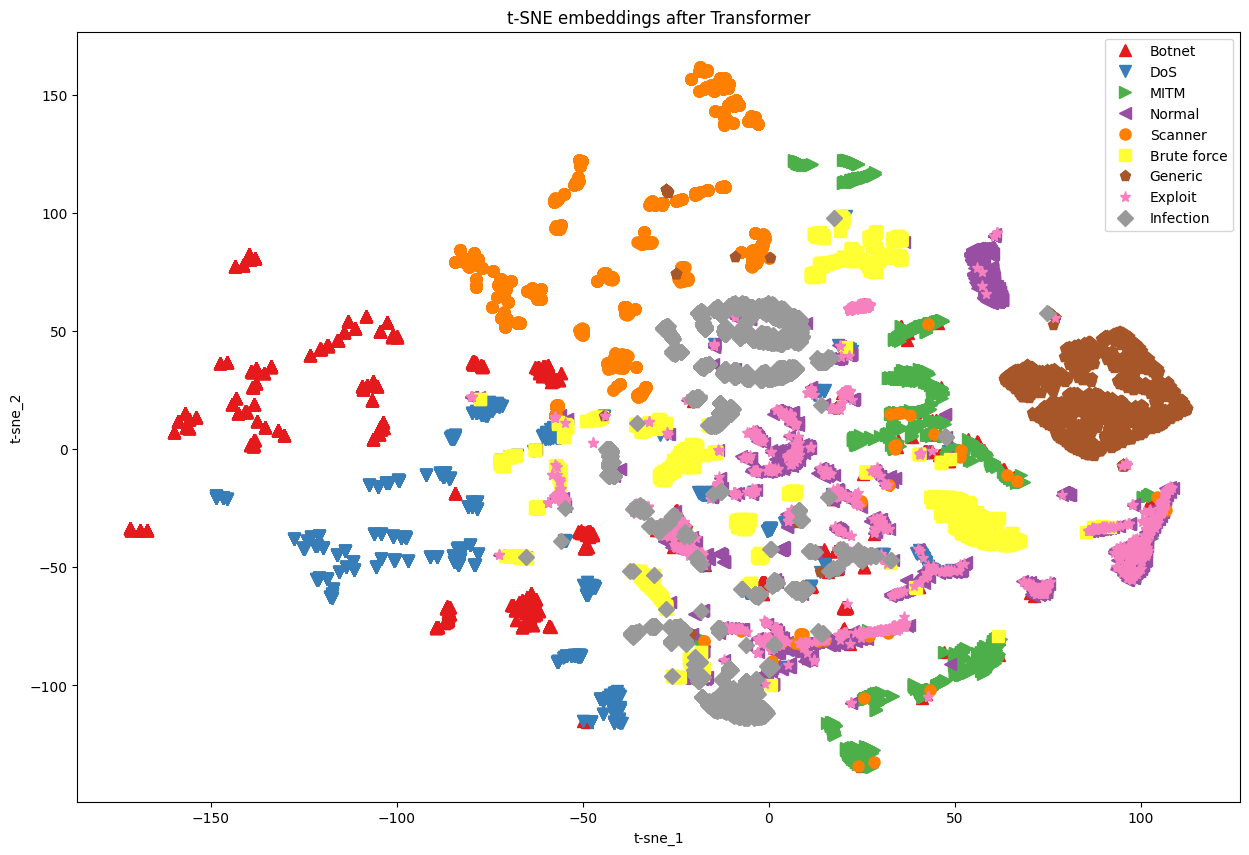

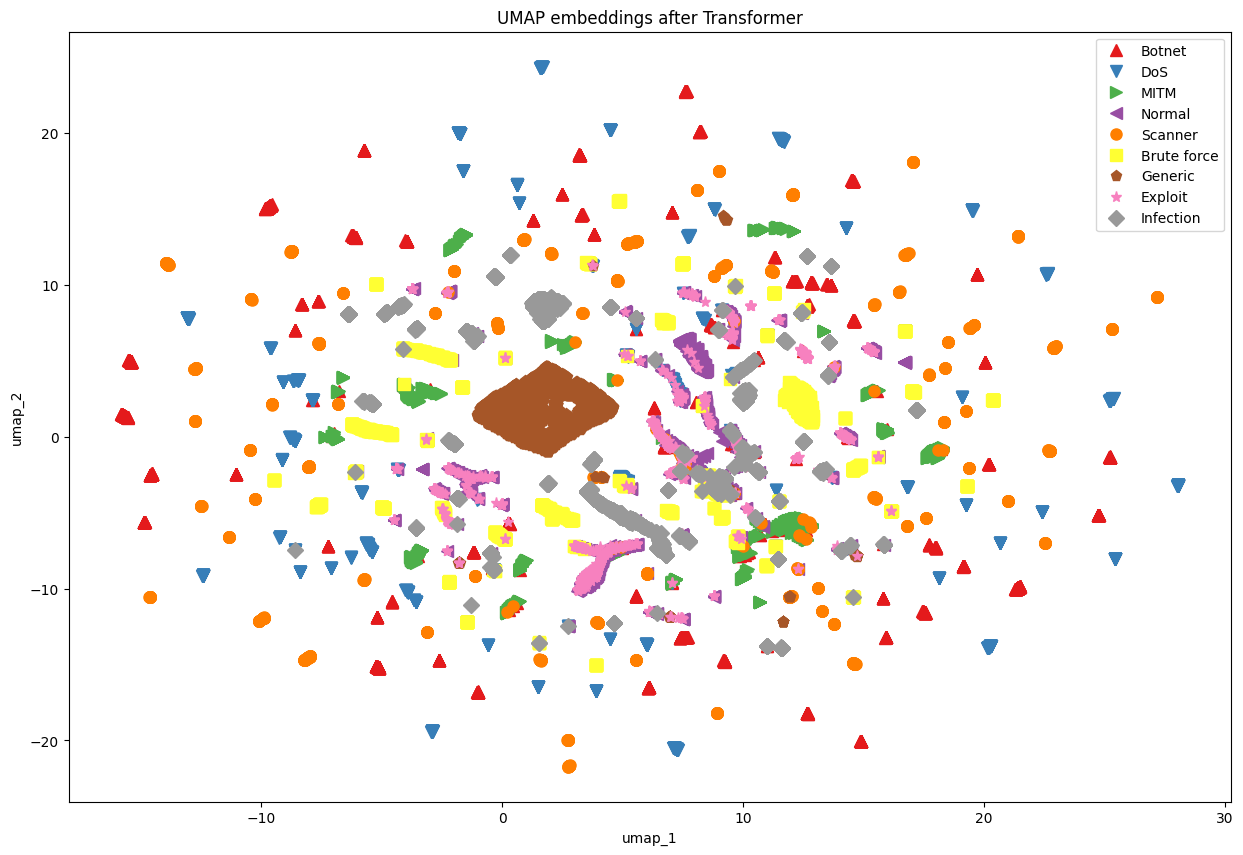

In [30]:
tsne_reducer = TSNE(n_components=2, perplexity=40, method="barnes_hut", n_jobs=-1, max_iter=2000)
transformer_model = MyTransformerModel(X_test.shape[1], n_classes, **transformer_removed_hyperparameters).to(DEVICE)
transformer_model.load_state_dict(torch.load(transformer_sep_removed_model_file, weights_only=True))
transformer_model.eval()
transformer_output = torch.empty((X_test.shape[0], 128), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_sep_removed_data, batch_size=batch_removed_size, pin_memory=True, num_workers=8, shuffle=False)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        n = data.shape[0]
        data = data.to(DEVICE)
        transformer_output[offset:offset+n] = transformer_model.transformer_layers(data)
        offset += n
assert offset == transformer_output.shape[0]

transformer_output = transformer_output.to("cpu")
embedding = tsne_reducer.fit_transform(transformer_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after Transformer")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=20, n_jobs=-1, min_dist=0.1)
embedding = umap_reducer.fit_transform(transformer_output)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings after Transformer")

**Unified removed network-specific features**

KL divergence: -0.39766398072242737


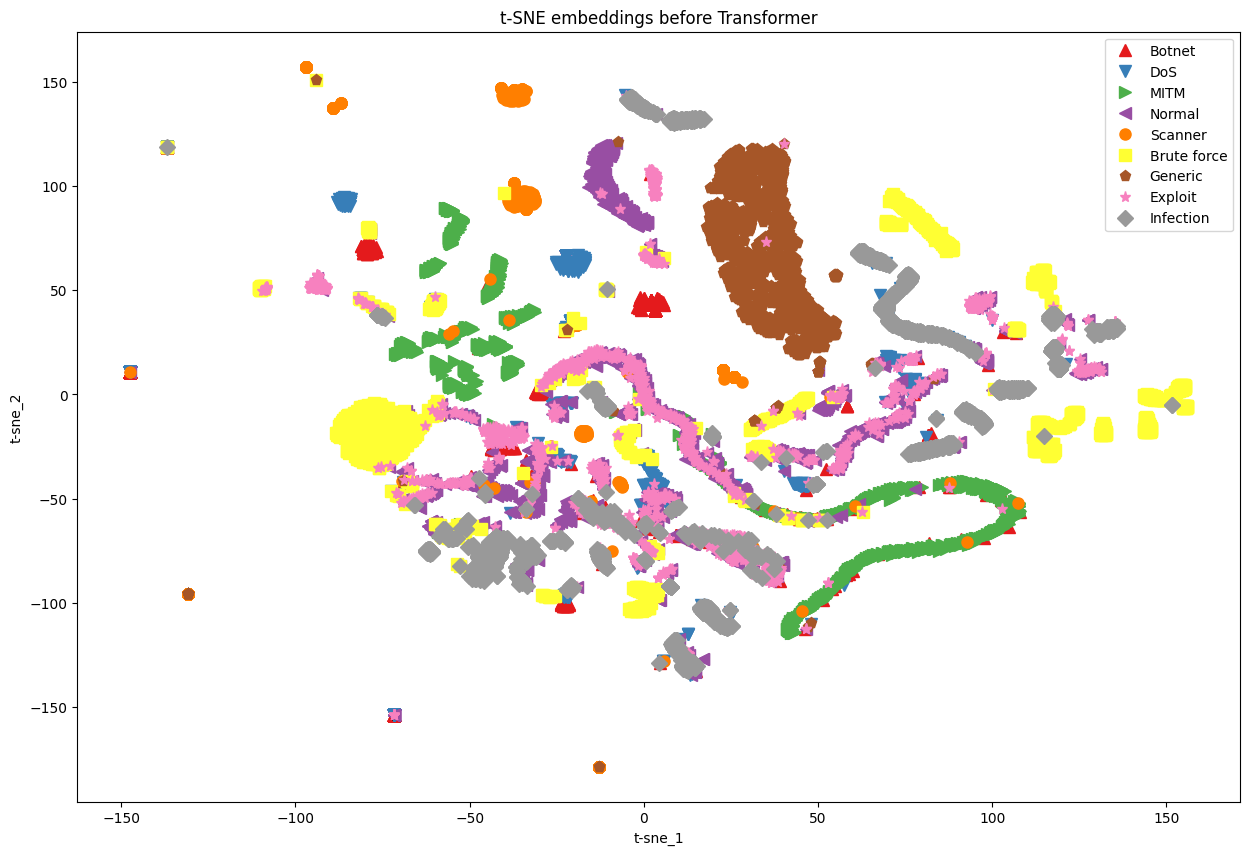

/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib64/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


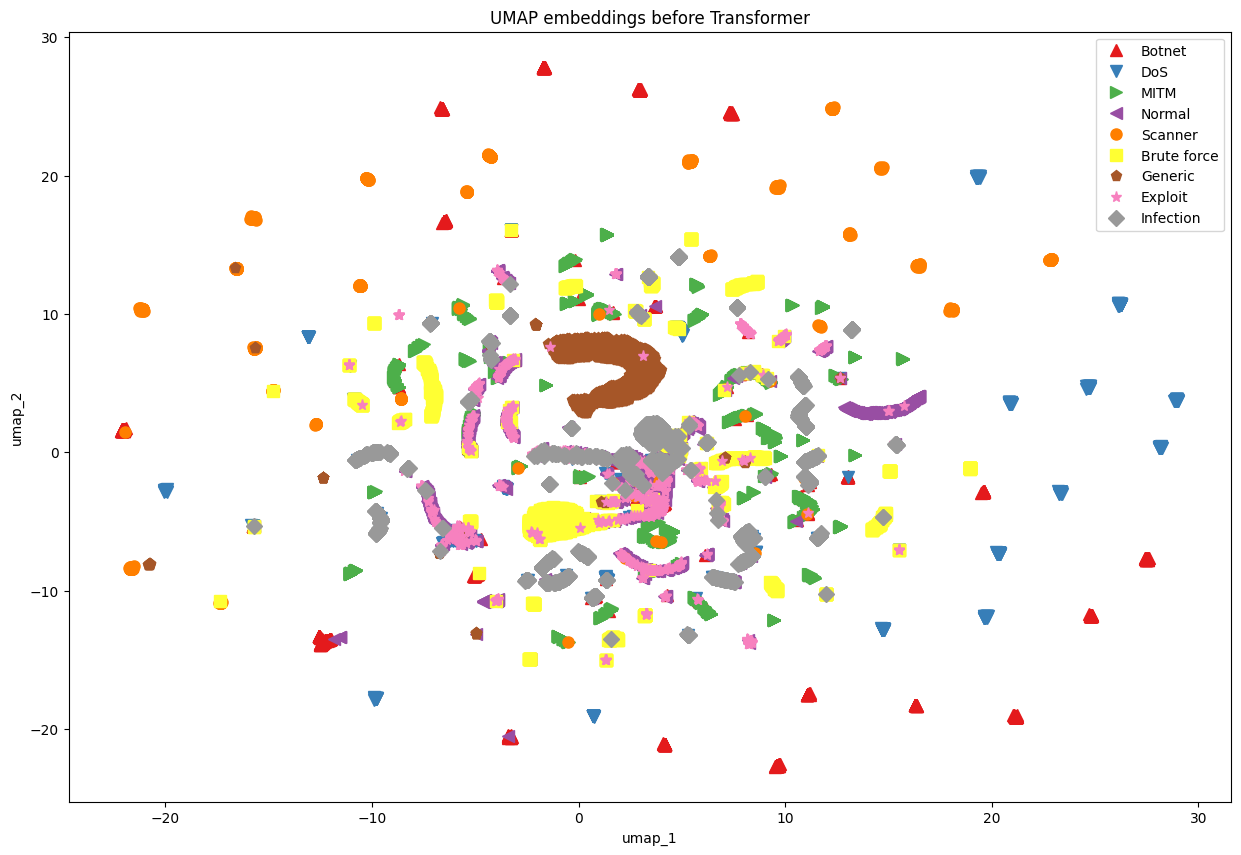

In [31]:
tsne_reducer = TSNE(n_components=2, perplexity=40, method="barnes_hut", n_jobs=-1, max_iter=2000)
X_test, y_test = test_uni_removed_data.dataset[test_uni_removed_data.indices][0], test_uni_removed_data.dataset[test_uni_removed_data.indices][1]
embedding = tsne_reducer.fit_transform(X_test)
print("KL divergence:", tsne_reducer.kl_divergence_)
embedding.shape
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings before Transformer")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=30, n_jobs=-1, min_dist=0.2)
embedding = umap_reducer.fit_transform(X_test)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings before Transformer")

74
KL divergence: 0.27809837460517883


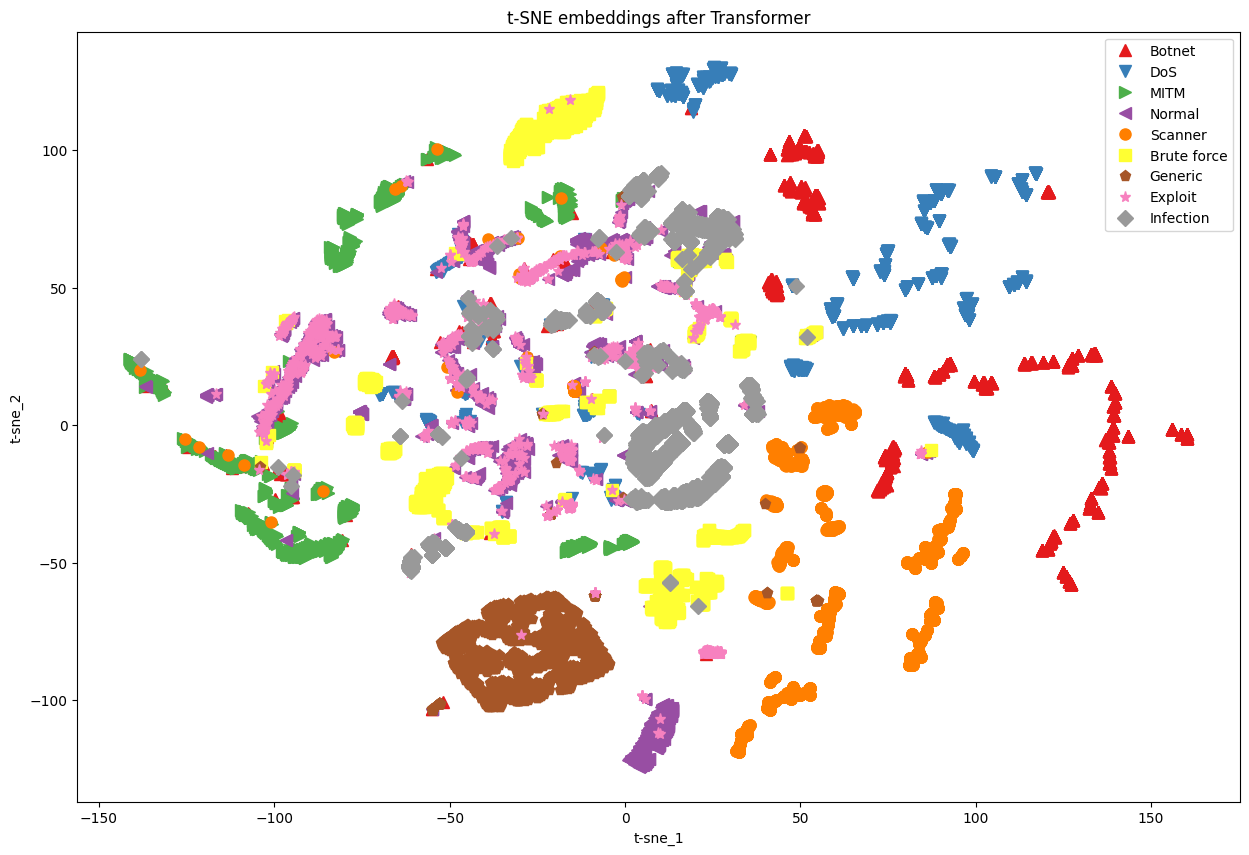

/home/sbaltsas/Visual_Studio_Code_Projects/thesis/.venv/lib64/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


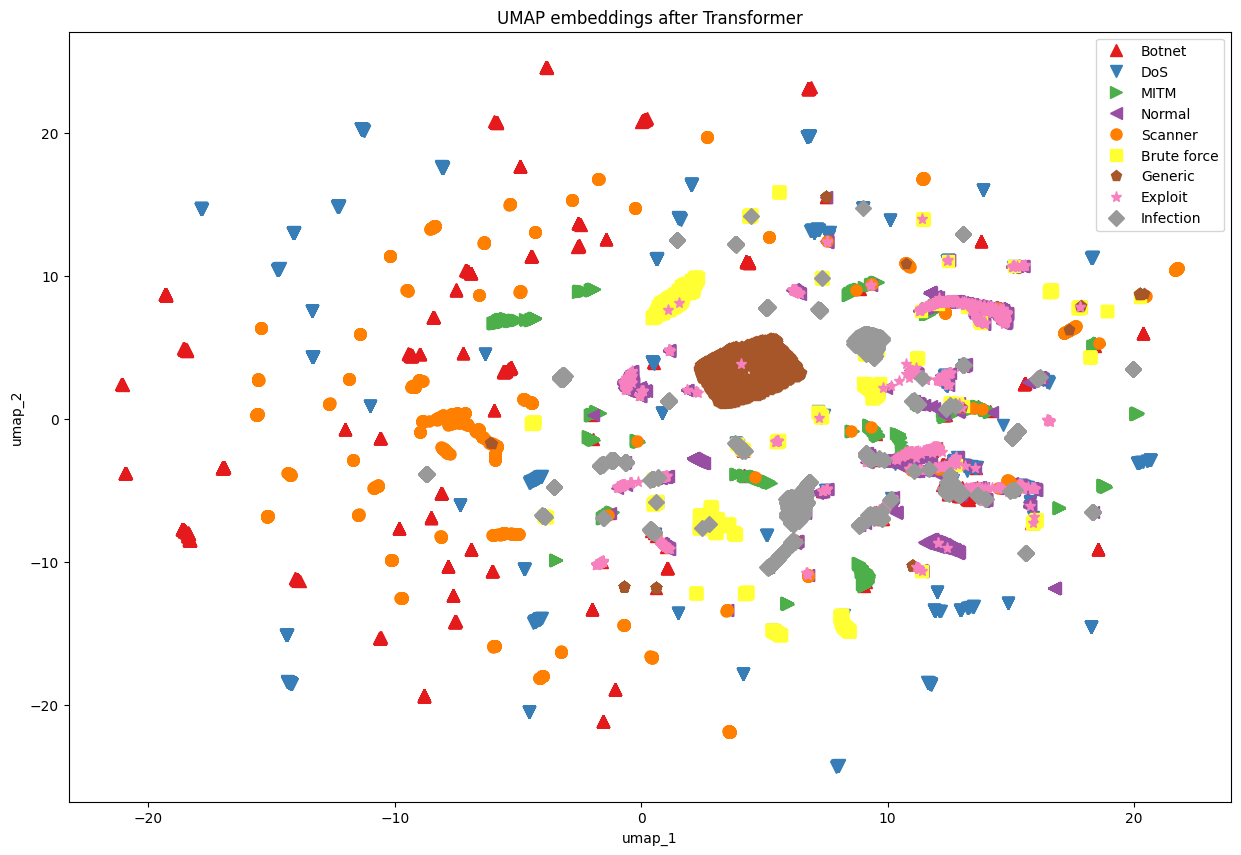

In [35]:
tsne_reducer = TSNE(n_components=2, perplexity=45, method="barnes_hut", n_jobs=-1, max_iter=2000)
transformer_model = MyTransformerModel(X_test.shape[1], n_classes, **transformer_removed_hyperparameters).to(DEVICE)
transformer_model.load_state_dict(torch.load(transformer_uni_removed_model_file, weights_only=True))
transformer_model.eval()
transformer_output = torch.empty((X_test.shape[0], 128), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_uni_removed_data, batch_size=batch_removed_size, pin_memory=True, num_workers=8, shuffle=False)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        n = data.shape[0]
        data = data.to(DEVICE)
        transformer_output[offset:offset+n] = transformer_model.transformer_layers(data)
        offset += n
assert offset == transformer_output.shape[0]

transformer_output = transformer_output.to("cpu")
embedding = tsne_reducer.fit_transform(transformer_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after Transformer")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=50, n_jobs=-1, min_dist=0.12)
embedding = umap_reducer.fit_transform(transformer_output)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings after Transformer")

#### LSTM

**LSTM model hyperparameter loading and training**


In [ ]:
lstm_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_lstm", "best_config_multiclass.json")
config = load_config(lstm_config_file)
learning_rate = config.pop("lr")
batch_size = config.pop("batch_size")
lstm_hyperparameters = config
lstm_hidden_states = config["hidden_lstm_states"]
lstm_model = MyLSTMClassifier(n_classes, **lstm_hyperparameters)

lstm_uni_removed_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_removed_features_lstm", "improved_removed_features_best_config.json")
config = load_config(lstm_uni_removed_config_file)
learning_uni_removed_rate = config.pop("lr")
batch_uni_removed_size = config.pop("batch_size")
lstm_uni_removed_hyperparameters = config
hidden_lstm_states_uni_removed = config["hidden_lstm_states"]

lstm_sep_removed_config_file = os.path.join(parent_dir, "results", "raytune", "test_raytune_removed_features_lstm", "removed_features_best_config_multiclass.json")
config = load_config(lstm_sep_removed_config_file)
learning_sep_removed_rate = config.pop("lr")
batch_sep_removed_size = config.pop("batch_size")
lstm_sep_removed_hyperparameters = config
hidden_lstm_states_sep_removed = config["hidden_lstm_states"]

lstm_sep_removed_model = MyLSTMClassifier(n_classes, **lstm_sep_removed_hyperparameters)
lstm_uni_removed_model = MyLSTMClassifier(n_classes, **lstm_uni_removed_hyperparameters)

# training transformer with all network specific features included
print("TRAINING LSTM WITH ALL NETWORK SPECIFIC FEATURES!")
train_data, test_data = random_split(dataset, [0.9, 0.1])
train_loader = DataLoader(train_data, batch_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
lstm_model.to(DEVICE)
ttutils.train_model(lstm_model, lstm_model_file, train_loader, None, metric=train_metric, learning_rate=learning_rate, epochs=LSTM_EPOCHS)
del lstm_model

# training transformer with unified removed network specific 
print("TRAINING LSTM WITH UNIFIED REMOVED NETWORK SPECIFIC FEATURES!")
train_uni_removed_data, test_uni_removed_data = random_split(dataset_unified_removed, [0.9, 0.1])
train_loader = DataLoader(train_uni_removed_data, batch_uni_removed_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
lstm_uni_removed_model.to(DEVICE)
ttutils.train_model(lstm_uni_removed_model, lstm_removed_uni_model_file, train_loader, None, metric=train_metric, 
                    learning_rate=learning_uni_removed_rate, epochs=LSTM_EPOCHS)
del lstm_uni_removed_model

# training transformer with all network specific features included
print("TRAINING LSTM WITH SEPARATE REMOVED NETWORK SPECIFIC FEATURES!")
train_sep_removed_data, test_sep_removed_data = random_split(dataset_lstm_removed, [0.9, 0.1])
train_loader = DataLoader(train_sep_removed_data, batch_size, shuffle=True, pin_memory=True, persistent_workers=True, num_workers=8)
train_metric = MulticlassAccuracy(average="macro", num_classes=n_classes, device=DEVICE)
lstm_sep_removed_model.to(DEVICE)
ttutils.train_model(lstm_sep_removed_model, lstm_removed_sep_model_file, train_loader, None, metric=train_metric, 
                    learning_rate=learning_sep_removed_rate, epochs=LSTM_EPOCHS)
del lstm_sep_removed_model

TRAINING LSTM WITH ALL NETWORK SPECIFIC FEATURES!
TRAINING LSTM WITH UNIFIED REMOVED NETWORK SPECIFIC FEATURES!
TRAINING LSTM WITH SEPARATE REMOVED NETWORK SPECIFIC FEATURES!


**With network specific features**

81
KL divergence: 0.5904713273048401


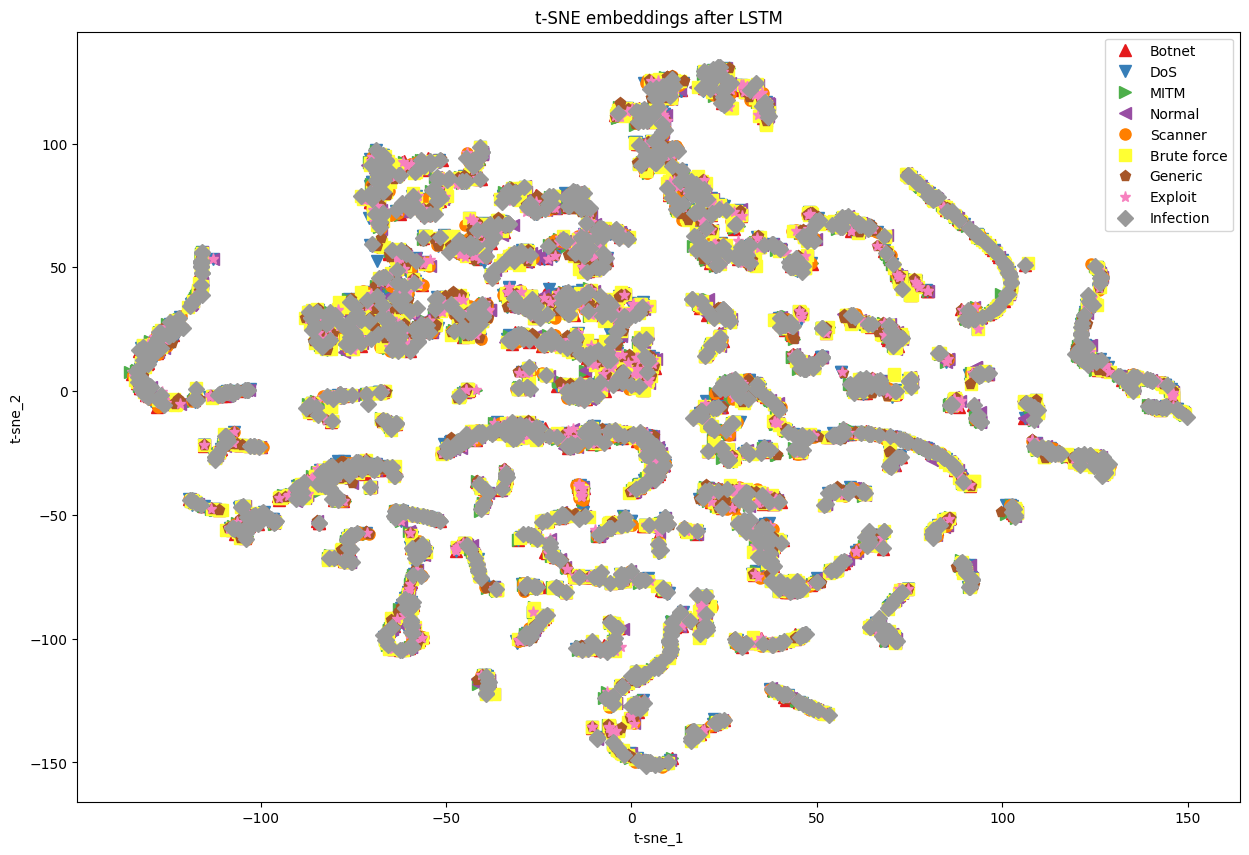

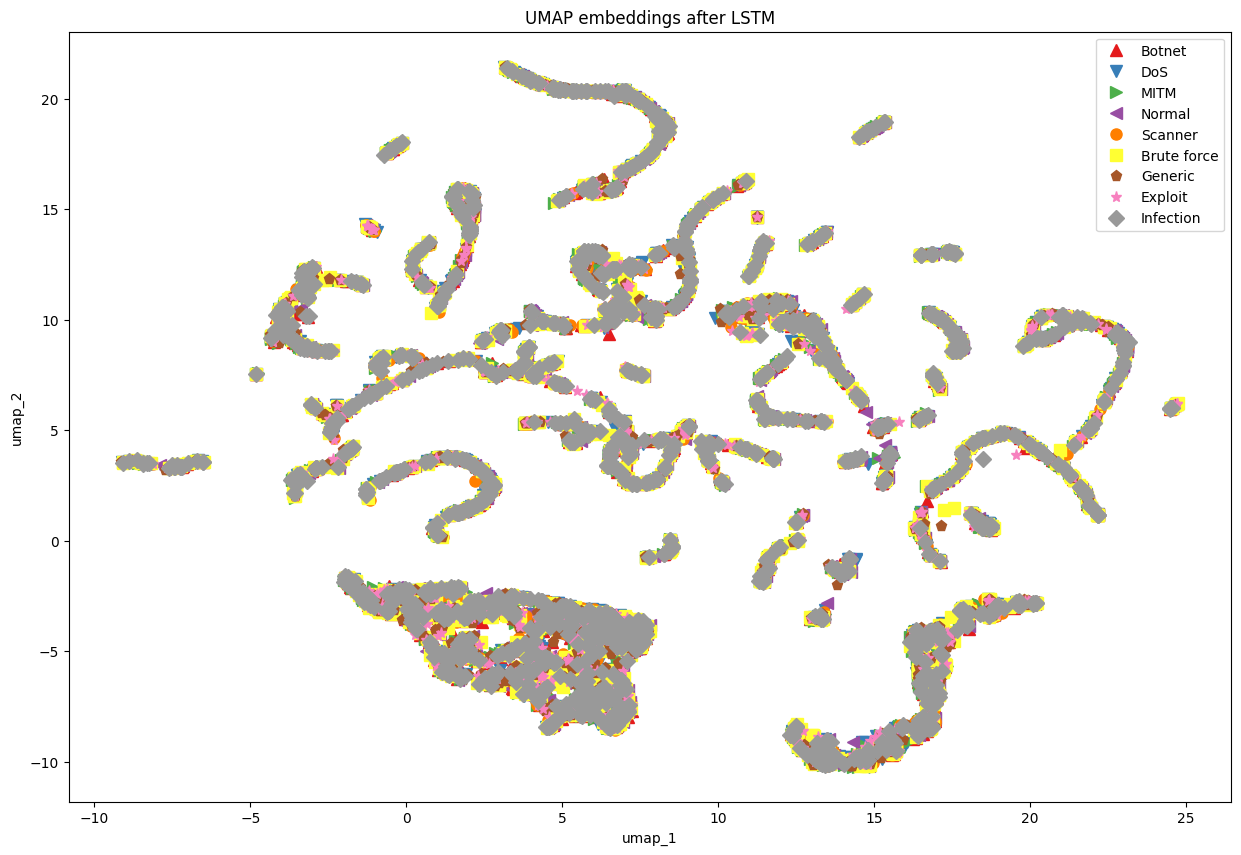

In [19]:
tsne_reducer = TSNE(n_components=2, perplexity=30, method="barnes_hut", n_jobs=-1, max_iter=2000)
umap_reducer = umap.UMAP(n_components=2, n_neighbors=25, n_jobs=-1, min_dist=0.2)
X_test, y_test = test_data.dataset[test_data.indices][0], test_data.dataset[test_data.indices][1]
lstm_model = MyLSTMClassifier(n_classes, **lstm_hyperparameters).to(DEVICE)
lstm_model.load_state_dict(torch.load(lstm_model_file, weights_only=True))
lstm_model.eval()
lstm_output = torch.empty((X_test.shape[0], lstm_model.hidden_lstm_states//2), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_uni_removed_data, batch_size=batch_size, pin_memory=True, num_workers=8, shuffle=False)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        n = data.shape[0]
        data = data.to(DEVICE)
        lstm_output[offset:offset+n] = lstm_model.lstm_layers(data)
        offset += n
assert offset == lstm_output.shape[0]

lstm_output = lstm_output.to("cpu")
embedding = tsne_reducer.fit_transform(lstm_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after LSTM")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=40, n_jobs=-1, min_dist=0.2)
embedding = umap_reducer.fit_transform(lstm_output)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings after LSTM")

**Unified removed network-specific features**

74
KL divergence: 0.543471097946167


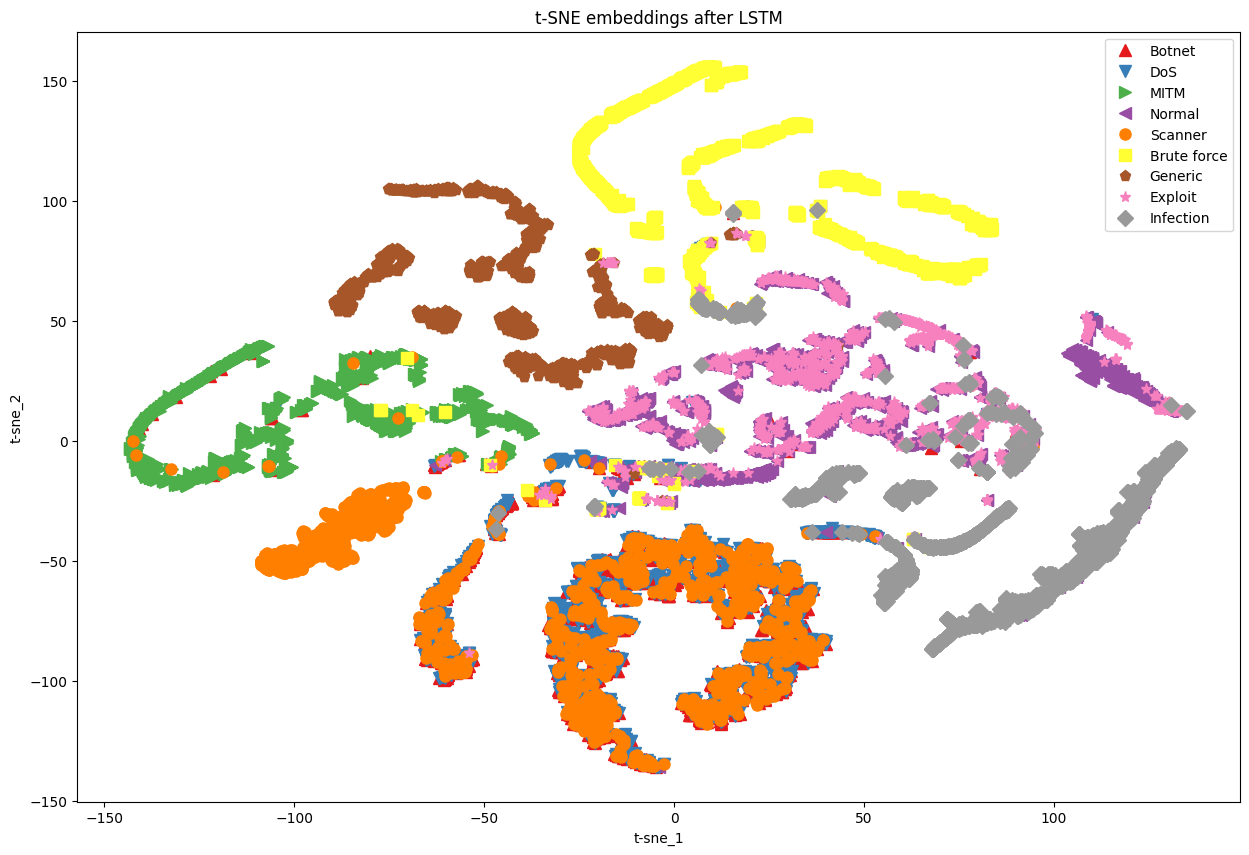

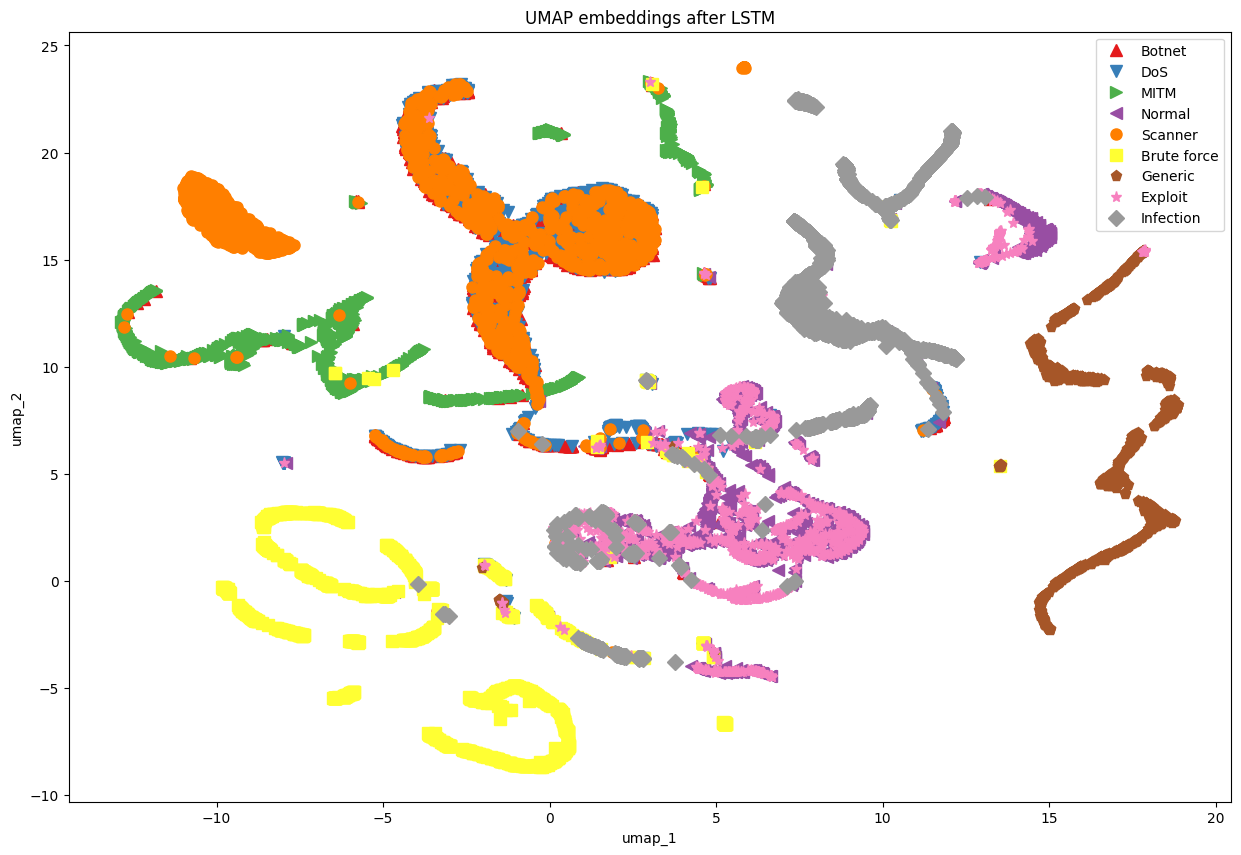

In [15]:
tsne_reducer = TSNE(n_components=2, perplexity=30, method="barnes_hut", n_jobs=-1, max_iter=2000)
umap_reducer = umap.UMAP(n_components=2, n_neighbors=25, n_jobs=-1, min_dist=0.2)
X_test, y_test = test_uni_removed_data.dataset[test_uni_removed_data.indices][0], test_uni_removed_data.dataset[test_uni_removed_data.indices][1]
lstm_model = MyLSTMClassifier(n_classes, **lstm_uni_removed_hyperparameters).to(DEVICE)
lstm_model.load_state_dict(torch.load(lstm_removed_uni_model_file, weights_only=True))
lstm_model.eval()
lstm_output = torch.empty((X_test.shape[0], lstm_model.hidden_lstm_states//2), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_uni_removed_data, batch_size=batch_uni_removed_size, pin_memory=True, num_workers=8, shuffle=False)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        n = data.shape[0]
        data = data.to(DEVICE)
        lstm_output[offset:offset+n] = lstm_model.lstm_layers(data)
        offset += n
assert offset == lstm_output.shape[0]

lstm_output = lstm_output.to("cpu")
embedding = tsne_reducer.fit_transform(lstm_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after LSTM")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=40, n_jobs=-1, min_dist=0.2)
embedding = umap_reducer.fit_transform(lstm_output)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings after LSTM")

**Separate removed network-specific features**

80
KL divergence: 0.5620437860488892


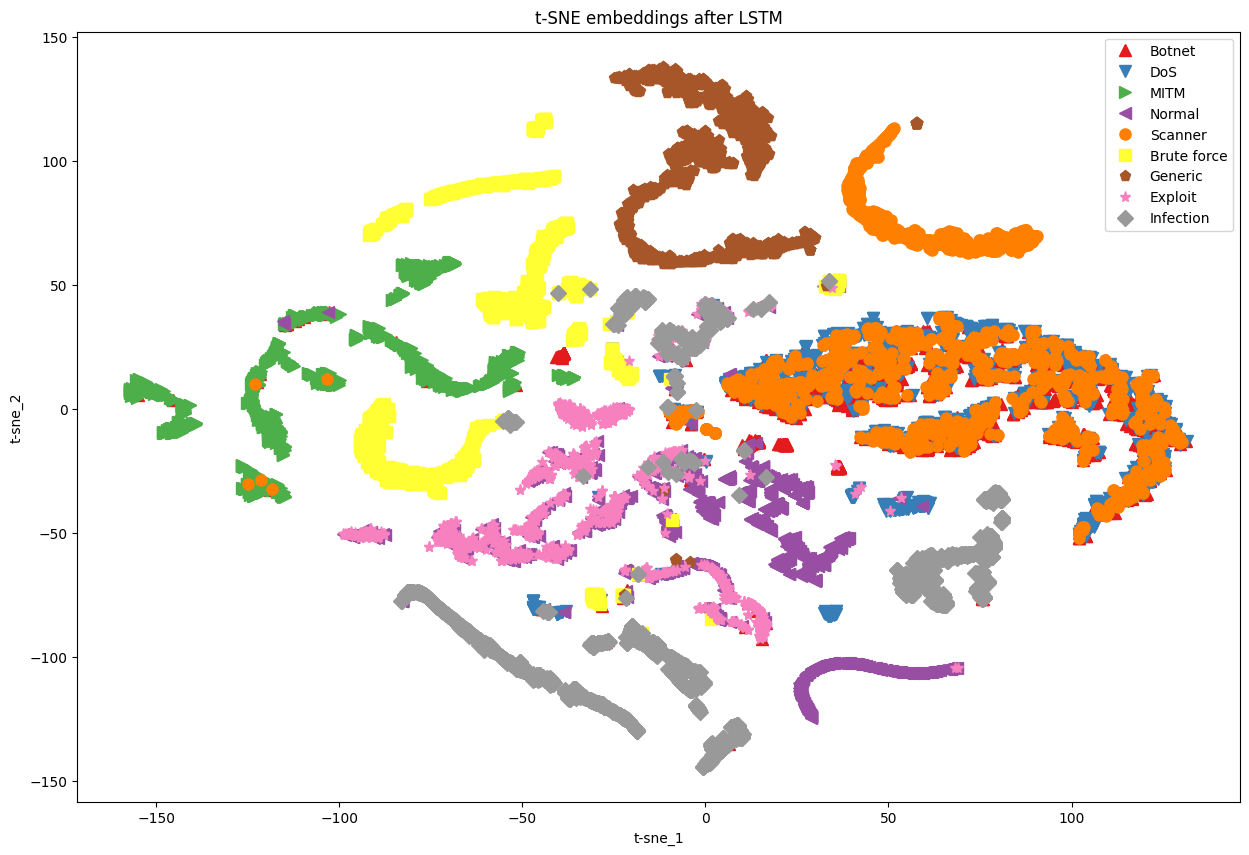

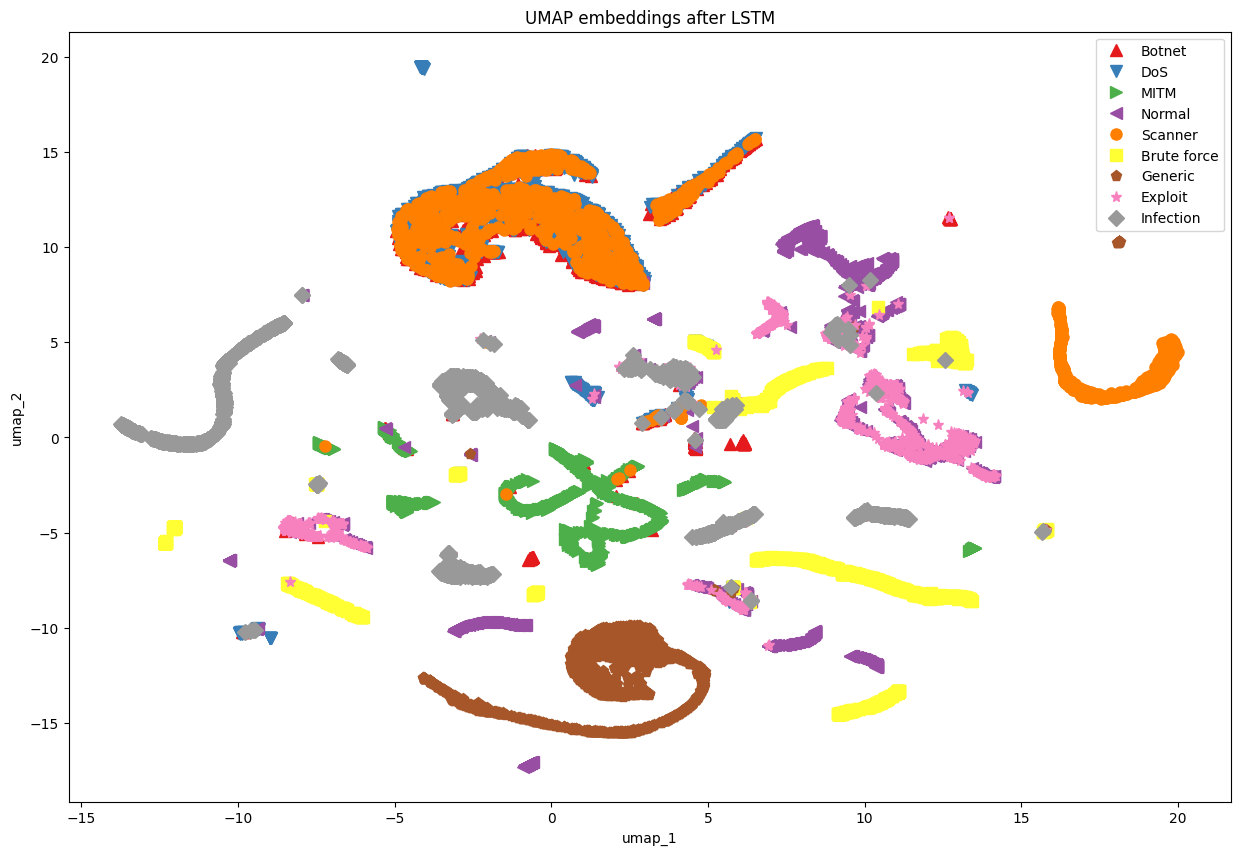

In [16]:
tsne_reducer = TSNE(n_components=2, perplexity=30, method="barnes_hut", n_jobs=-1, max_iter=2000)
umap_reducer = umap.UMAP(n_components=2, n_neighbors=25, n_jobs=-1, min_dist=0.2)
X_test, y_test = test_sep_removed_data.dataset[test_sep_removed_data.indices][0], test_sep_removed_data.dataset[test_sep_removed_data.indices][1]
lstm_model = MyLSTMClassifier(n_classes, **lstm_sep_removed_hyperparameters).to(DEVICE)
lstm_model.load_state_dict(torch.load(lstm_removed_sep_model_file, weights_only=True))
lstm_model.eval()
lstm_output = torch.empty((X_test.shape[0], lstm_model.hidden_lstm_states//2), dtype=torch.float32).to(DEVICE)
dataloader = DataLoader(test_sep_removed_data, batch_size=batch_sep_removed_size, pin_memory=True, num_workers=8, shuffle=False)
offset = 0
print(X_test.shape[1])
with torch.inference_mode():
    for data, label in dataloader:
        n = data.shape[0]
        data = data.to(DEVICE)
        lstm_output[offset:offset+n] = lstm_model.lstm_layers(data)
        offset += n
assert offset == lstm_output.shape[0]

lstm_output = lstm_output.to("cpu")
embedding = tsne_reducer.fit_transform(lstm_output)
print("KL divergence:", tsne_reducer.kl_divergence_)
plot_embedding(embedding, y_test, "t-sne", "t-SNE embeddings after LSTM")

umap_reducer = umap.UMAP(n_components=2, n_neighbors=40, n_jobs=-1, min_dist=0.2)
embedding = umap_reducer.fit_transform(lstm_output)
plot_embedding(embedding, y_test, "umap", "UMAP embeddings after LSTM")